# VLM — Estimating Box Distance with a Depth Map

Generate a depth map from an image, then pass both the original image and depth map to Gemini to estimate how far away each box is.

In [1]:
!pip install google-genai transformers torch pillow httpx matplotlib python-dotenv


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os, io, json, httpx
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from dotenv import load_dotenv
from transformers import pipeline
from google import genai

load_dotenv(dotenv_path=os.path.join(os.path.dirname(os.getcwd()), ".env"))

vlm = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])
MODEL = "gemini-2.5-flash"

depth_pipe = pipeline("depth-estimation", model="depth-anything/Depth-Anything-V2-Small-hf")

/Users/charlierobison/Desktop/Github/charlie-robison/hfa-ai-training/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 287/287 [00:00<00:00, 7341.11it/s]


In [3]:
# --- Load image and generate depth map ---

IMAGE_URL = "https://images.squarespace-cdn.com/content/v1/599468f3d482e9e0ce062689/6e8eaa07-464a-4ee1-a6c0-0a08b6f15fa4/Trade_Show_Crate_2Door_Heavy_Duty_2022_06456.jpg"

image_data = httpx.get(IMAGE_URL).content
original = Image.open(io.BytesIO(image_data)).convert("RGB")

# Generate depth map (brighter = closer, darker = farther)
depth_result = depth_pipe(original)
depth_map = depth_result["depth"]  # PIL Image

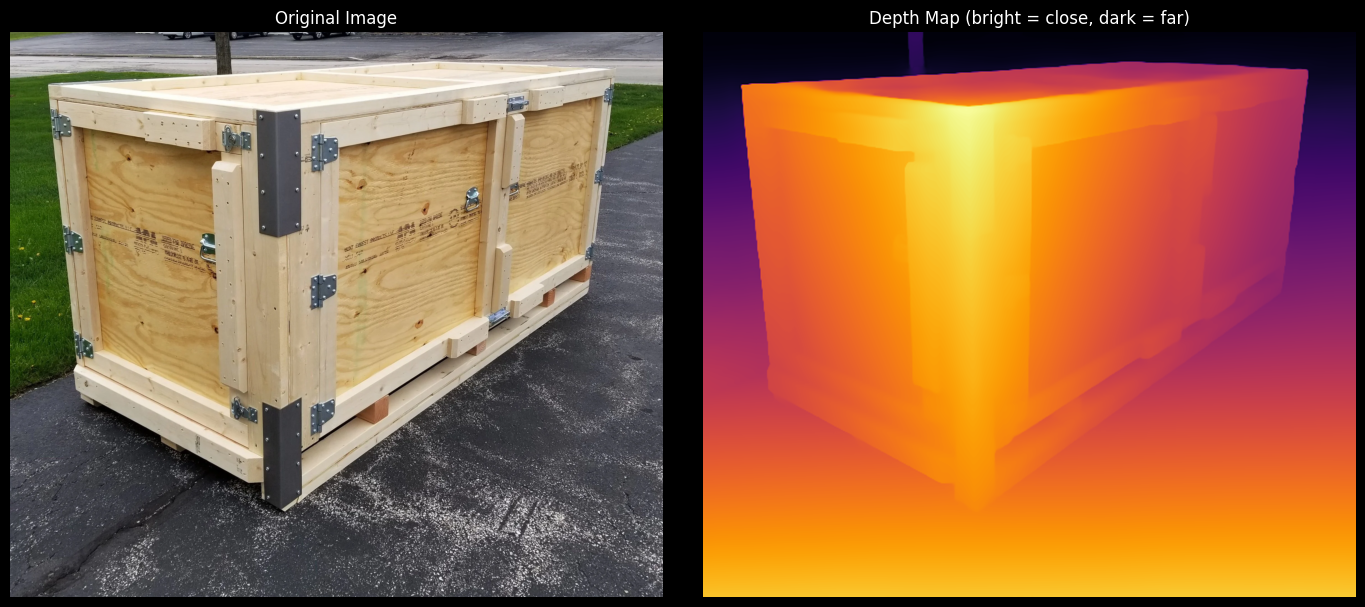

In [4]:
# --- Display original image and depth map side by side ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.imshow(original)
ax1.set_title("Original Image")
ax1.axis("off")

ax2.imshow(depth_map, cmap="inferno")
ax2.set_title("Depth Map (bright = close, dark = far)")
ax2.axis("off")

plt.tight_layout()
plt.show()

In [5]:
# --- Send BOTH images to Gemini for analysis ---

# Convert depth map to RGB so Gemini can read it
depth_rgb = depth_map.convert("RGB")

PROMPT = """
You are given two images:
1. The ORIGINAL photo of a scene with boxes/pallets/cartons.
2. A DEPTH MAP of the same scene where brighter areas are closer to the
   camera and darker areas are farther away.

Use BOTH images together to identify every box, carton, or pallet visible.
Use the depth map to improve your distance estimates.

For each box, provide:
- distance_ft: estimated distance from the camera in feet (use the depth map)
- size: small / medium / large
- position: where in the frame (left/center/right, foreground/midground/background)
- labels: any visible text or markings, or "none"
- description: one-line description

Respond ONLY with this JSON:
{
  "box_count": <int>,
  "boxes": [
    {
      "id": 1,
      "distance_ft": <float>,
      "size": "small | medium | large",
      "position": "<position>",
      "labels": "<text or none>",
      "description": "<brief>"
    }
  ],
  "scene_description": "<one sentence>"
}
"""

response = vlm.models.generate_content(
    model=MODEL,
    contents=[original, depth_rgb, PROMPT],
)

# Parse JSON from response
text = response.text.strip()
if text.startswith("```"):
    text = text.split("\n", 1)[1]
if text.endswith("```"):
    text = text.rsplit("```", 1)[0]

result = json.loads(text)

In [6]:
# --- Results ---

print(f"Scene: {result['scene_description']}")
print(f"Boxes found: {result['box_count']}\n")

for box in result["boxes"]:
    print(f"  Box #{box['id']}  —  ~{box['distance_ft']} ft away")
    print(f"    Size: {box['size']}  |  Position: {box['position']}")
    print(f"    Labels: {box['labels']}")
    print(f"    {box['description']}\n")

print("\n--- Full JSON ---")
print(json.dumps(result, indent=2))

Scene: A single large wooden shipping crate is prominently displayed in the center foreground of an outdoor scene on an asphalt driveway, with grass and trees in the distant background.
Boxes found: 1

  Box #1  —  ~7.0 ft away
    Size: large  |  Position: center foreground
    Labels: PRODUCT LOGISTICS LLC, P/N: 2110-0016-003 REV A, MFG DATE 02/2023
    A large wooden shipping crate with metal hinges and corner brackets, sitting on an asphalt surface.


--- Full JSON ---
{
  "box_count": 1,
  "boxes": [
    {
      "id": 1,
      "distance_ft": 7.0,
      "size": "large",
      "position": "center foreground",
      "labels": "PRODUCT LOGISTICS LLC, P/N: 2110-0016-003 REV A, MFG DATE 02/2023",
      "description": "A large wooden shipping crate with metal hinges and corner brackets, sitting on an asphalt surface."
    }
  ],
  "scene_description": "A single large wooden shipping crate is prominently displayed in the center foreground of an outdoor scene on an asphalt driveway, with g